# 02 Linguistic Analysis

This notebook analyzes how Martin Luther King Jr. (MLK) moves between standard and elevated language across sermons and speeches.

Rather than asking whether a speech is simple or sophisticated overall, this notebook asks:



*   **Is there a rhythm of movement between simplicity and sophistication in MLK's speeches/sermons?**



Each sentence is treated as a single rhetorical state. The resulting sequence lets us study MLK's linguistic "dance" over time.


## ~1. Defining our Linguistic Measures

In this project, we attempt to capture MLK's *linguistic elevation,* which refers to the degree to which a sentence rises in sophisticated language. Sophisticated sentences will have more extended, complex, rare, or abstract language compared to other sentences within the same speech/sermon.

Please note:

- Simple does *not* mean weak or bad.
- Sophisticated does *not* mean powerful or better.
- The goal is to study movement between the two modes.

We will calculate linguistic elevation using five features:

| Feature | Meaning |
|---|---|
| `word_count` | How extended the sentence is |
| `avg_syllables_per_word` | How sonically/phonologically complex the words are |
| `rare_word_ratio` | How uncommon the words are |
| `abstract_word_ratio` | How conceptual, moral, spiritual, or philosophical the language is |


## ~2. Importing Libraries

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 50)


## ~3. Defining Project Paths

Project structure:

```text
mlk-rhetoric-analysis/
├── data/
│   ├── cleaned_transcripts/
│   ├── linguistic_elevation/
├── visuals/
└── notebooks/


```


In [2]:
# Removing any files from local disk
# !rm -rf /content/drive

# Make sure Google Drive is mounted first:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/mlk_rhetoric_analysis")

sentence_transcripts_dir = BASE_DIR / "data" / "cleaned_transcripts"
output_dir = BASE_DIR / "data" / "linguistic_elevation"
visuals_dir = BASE_DIR / "visuals"

print("Project root:", BASE_DIR)
print("Sentence transcripts folder:", sentence_transcripts_dir)
print("Output folder:", output_dir)
print("Visuals folder:", visuals_dir)


Mounted at /content/drive
Project root: /content/drive/MyDrive/mlk_rhetoric_analysis
Sentence transcripts folder: /content/drive/MyDrive/mlk_rhetoric_analysis/data/cleaned_transcripts
Output folder: /content/drive/MyDrive/mlk_rhetoric_analysis/data/linguistic_elevation
Visuals folder: /content/drive/MyDrive/mlk_rhetoric_analysis/visuals


## ~4. Loading Sentence-Split Transcript Files

We will analyze sentence-level transcripts of 16 speeches/sermons delivered by MLK, spanning 1953-1967.

Each non-empty line in each `.txt` file is treated as one sentence.

The output dataframe has one row per sentence.


In [3]:
transcript_files = sorted(sentence_transcripts_dir.glob("*sentences.txt"))

print(f"Found {len(transcript_files)} transcript files.")
for file in transcript_files[:10]:
    print("-", file.name)


Found 16 transcript files.
- #MLK _ But, If Not_sentences.txt
- #MLK _ Nobel Peace Prize Lecture. Oslo, Norway. December 11, 1964._sentences.txt
- Beyond Vietnam-A Time to Break Silence 4-4-67_sentences.txt
- I Have Been to the Mountaintop Full Speech_sentences.txt
- MLKDream_64kb_sentences.txt
- MLK_ On Peace and Nonviolence_sentences.txt
- MLK_ Paul's Letter to American Christians_sentences.txt
- MLK_ The Other America_sentences.txt
- Martin Luther King Jr. 'Love Your Enemies' November 17, 1957_sentences.txt
- Martin Luther King Jr. 'Rediscovering Lost Values' February 28, 1954_sentences.txt


In [4]:
records = []

for file_path in transcript_files:
    speech_id = file_path.stem
    lines = file_path.read_text(encoding="utf-8").splitlines()
    sentences = [line.strip() for line in lines if line.strip()]

    for i, sentence in enumerate(sentences):
        records.append({
            "speech_id": speech_id,
            "sentence_index": i,
            "sentence": sentence
        })

sentences_df = pd.DataFrame(records)

print(f"Loaded {len(sentences_df)} total sentences.")
sentences_df.head()


Loaded 3224 total sentences.


,speech_id,sentence_index,sentence
0,"#MLK _ But, If Not_sentences",0,"But, if not, there was a day when many of the Israelites found themselves in bondage in Babylon."
1,"#MLK _ But, If Not_sentences",1,There was a king of Babylon by the name of Nebuchadnezzar.
2,"#MLK _ But, If Not_sentences",2,You read about him a good deal in the Book of Daniel and it stands as an epic that will remain stencil on the mental sheets of unfolding generations.
3,"#MLK _ But, If Not_sentences",3,Nebuchadnezzar was a mighty king and when he ruled he ruled and when he issued an order he meant business.
4,"#MLK _ But, If Not_sentences",4,Nebuchadnezzar issued an order.


## ~5. Feature Engineering

We calculate four sentence-level features:

1. `word_count`
2. `avg_syllables_per_word`
3. `rare_word_ratio`
4. `abstract_word_ratio`


### 5.1 Helper Functions

These functions tokenize words, estimate syllables, and compute feature values.

Note these features are approximate because the goal is exploratory analysis, not perfect phonetic transcription.


In [5]:
def tokenize_words(text):
    """Return lowercase alphabetic word tokens, preserving apostrophes inside words."""
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", text.lower())


def estimate_syllables(word):
    """Approximate syllable count for an English word."""
    word = word.lower().strip()
    if not word:
        return 0

    vowels = "aeiouy"
    count = 0
    previous_is_vowel = False

    for char in word:
        is_vowel = char in vowels
        if is_vowel and not previous_is_vowel:
            count += 1
        previous_is_vowel = is_vowel

    if word.endswith("e") and count > 1:
        count -= 1

    return max(count, 1)


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0


### 5.2 Define Common and Abstract Word Lists

`rare_word_ratio` uses a simple common-word list. Words not in the common list are treated as rare.

`abstract_word_ratio` uses a custom vocabulary list connected to moral, spiritual, philosophical, political, and conceptual language.

Note these lists are design choices for our exploratory analysis.


In [6]:
common_words = set("""
the be to of and a in that have i it for not on with he as you do at this but his by from
they we say her she or an will my one all would there their what so up out if about who get
which go me when make can like time no just him know take people into year your good some could
them see other than then now look only come its over think also back after use two how our work
first well way even new want because any these give day most us is are was were am been being has had
shall should may might must every each many much more such where why through before again here there
man men woman women child children life lives world nation country city house home place thing things
come came go went see saw know knew make made let said tell told hear heard stand stood walk walked
right wrong great little long short old young today tomorrow yesterday night morning hand hands heart

really very always never often sometimes maybe perhaps almost already still yet ever far near around across
within without under above below between during toward towards against among beside besideupon beyond inside
outside upon across throughout along beneath underneath whenever wherever however whatever whoever whom whose

yes yeah nope okay ok sure certainly absolutely definitely probably likely unlikely obviously clearly simply
basically actually literally truly honestly generally specifically especially primarily mainly mostly entirely
completely fully partly partially relatively approximately exactly precisely quickly slowly suddenly gradually

person persons somebody someone anybody anyone everybody everyone nobody none something anything everything
nothing self selves myself yourself himself herself ourselves themselves itself ourselves one another eachother

eat ate drink drank sleep slept wake woke sit sat run ran jump jumped drive drove ride rode bring brought
buy bought sell sold pay paid speak spoke talk talked call called ask asked answer answered write wrote read
open opened close closed begin began start started stop stopped finish finished continue continued happen
happened change changed move moved live lived die died grow grew feel felt become became remain remained

school teacher student students class classes lesson lessons learning learned study studied education college
university job jobs office business company companies service services program programs project projects team
teams meeting meetings group groups community communities family families parent parents mother father brother
sister friends friend neighbor neighbors relationship relationships marriage married single together apart

food water bread milk coffee tea dinner lunch breakfast fruit vegetables meat rice chicken fish sugar salt
money dollar dollars cost price value market markets store stores shop shops car cars bus train airplane road
street streets building buildings room rooms bed table chair phone computer computers internet television tv

black white red blue green yellow orange purple brown gray small big larger smaller biggest smallest better
best worse worst high low higher lower highest lowest early late earlier later easy hard difficult simple
complex important unimportant strong weak stronger weaker possible impossible necessary unnecessary

today tonight tomorrow yesterday monday tuesday wednesday thursday friday saturday sunday january february
march april may june july august september october november december spring summer fall winter season seasons

here there everywhere somewhere nowhere home away inside outside local national international public private
north south east west central urban rural domestic foreign nearby distant close closer closest farther farthest

believe believed believing think thought thinking understand understood understanding remember remembered
forget forgot forgotten imagine imagined imagining hope hoped hoping fear feared fearing love loved loving
hate hated hating care cared caring trust trusted trusting doubt doubted doubting mean meant meaning

""".split())

abstract_words = set("""
justice freedom equality liberty democracy morality moral conscience dignity hope faith love peace truth
righteousness redemption salvation grace mercy evil good goodness oppression liberation destiny dream vision
promise soul spirit spiritual brotherhood sisterhood unity community humanity human rights courage sacrifice
suffering struggle nonviolence violence transformation revolution movement future history historical sacred
divine god lord christ church kingdom eternal principle principles ideal ideals american america citizenship
injustice poverty wealth power powerless accountability responsibility creative redemptive reconciliation
beloved universe prophetic prophecy despair faithfulness discipline humility segregation integration
discrimination emancipation independence interdependence

wisdom transcendence transcendent transcendental enlightenment illumination revelation awakening awakeningness
virtue ethical ethics integrity compassion empathy sympathy forgiveness reconciliation healing restoration
restorative reconciliation reconciliationism reconciliationist stewardship service servant servanthood ministry
minister pastoral discipleship devotion devotionals devotionally prayer worship holiness holy sanctification
sanctified sanctify sacredness sacredly divinity divineness heavenly heaven paradise providence providential
gracious gracefulness merciful mercyfulness benevolence benevolent charity charitable altruism altruistic
humility humbleness meekness gentleness patience endurance perseverance steadfastness resilience courageously
sacrifice sacrificial suffering afflicted affliction lament lamentation sorrow grieving mourning redemption
deliverance liberation emancipatory emancipate emancipated freedomhood justice-oriented righteousnessness

humanism humanistic existential existentialism phenomenology ontology epistemology metaphysics metaphysical
dialectic dialectical ethics ethicality morality immorality consciousness selfhood identity meaning purpose
purposefulness flourishing flourishingness transcendence transcendentalism absurdity absurd existentiality
interconnectedness interdependence relationality solidarity collectivity collectivism communal communityhood
belonging belongingness personhood humanization dehumanization alienation authenticity authentic authenticness
agency empowerment disenfranchisement liberationist liberationism oppressionist resistance revolutionary reform
reformation awakening renewal rebirth regeneration transformation transformative transformational destinyhood

belovedness neighborliness fellowship communion communionism reconciliation restorative restorativejustice
justice-seeking peacemaking peacemaker peacemakers faithfulness spiritualism spirituality sacredness holiness
kingdom-minded kingdom-building propheticness prophecy prophetic witness testimony testimonies witnessing gospel
scripture biblical biblically theological theology eschatology disciples apostolic pastorality shepherding
mission missionary evangelism evangelistic incarnation incarnational resurrection crucifixion crucified cross
atonement covenant covenantal sanctity sanctified sanctification glorification glorify exaltation exalted
divinity transcendence eternalness everlasting immortality immortal salvationist redemptive grace-filled

democratic civic civility citizenship constitutional constitutionalism dignity-centered equality-centered
justice-centered liberation-centered humanity-centered compassionate ethical moral visionary visionaryness
idealistic idealism principled principledness courage-filled hopefulness hopelessness despairing resilience
resilient restorative transformative prophetic visionary aspirational aspiration dreaming dreamlike imagined
imagination imaginative imaginational moral imagination collective memory historical consciousness
""".split())


### 5.3 Calculate Raw Features

In [7]:
feature_records = []

for _, row in sentences_df.iterrows():
    words = tokenize_words(row["sentence"])
    word_count = len(words)
    syllable_count = sum(estimate_syllables(word) for word in words)
    rare_word_count = sum(1 for word in words if word not in common_words)
    abstract_word_count = sum(1 for word in words if word in abstract_words)

    feature_records.append({
        "word_count": word_count,
        "avg_syllables_per_word": safe_divide(syllable_count, word_count),
        "rare_word_ratio": safe_divide(rare_word_count, word_count),
        "abstract_word_ratio": safe_divide(abstract_word_count, word_count)
    })

features_df = pd.DataFrame(feature_records)
analysis_df = pd.concat([sentences_df, features_df], axis=1)

analysis_df.head()


,speech_id,sentence_index,sentence,word_count,avg_syllables_per_word,rare_word_ratio,abstract_word_ratio
0,"#MLK _ But, If Not_sentences",0,"But, if not, there was a day when many of the Israelites found themselves in bondage in Babylon.",18,1.500000,0.222222,0.000000
1,"#MLK _ But, If Not_sentences",1,There was a king of Babylon by the name of Nebuchadnezzar.,11,1.545455,0.363636,0.000000
2,"#MLK _ But, If Not_sentences",2,You read about him a good deal in the Book of Daniel and it stands as an epic that will remain stencil on the mental sheets of unfolding generations.,29,1.379310,0.344828,0.034483
3,"#MLK _ But, If Not_sentences",3,Nebuchadnezzar was a mighty king and when he ruled he ruled and when he issued an order he meant business.,20,1.550000,0.350000,0.000000
4,"#MLK _ But, If Not_sentences",4,Nebuchadnezzar issued an order.,4,2.500000,0.750000,0.000000


### 5.4 Analyzing Feature Distributions

We inspect the distributions of our engineered features to identify extreme skewness and determine whether normalization or transformation is needed before constructing the composite score.

Transforming extremely skewed features helps prevent a small number of unusually large values from disproportionately dominating the composite linguistic elevation score.

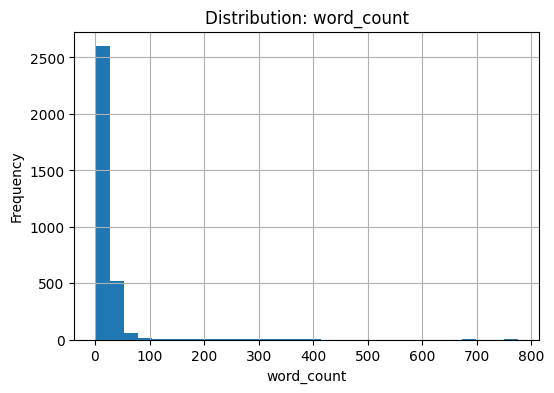

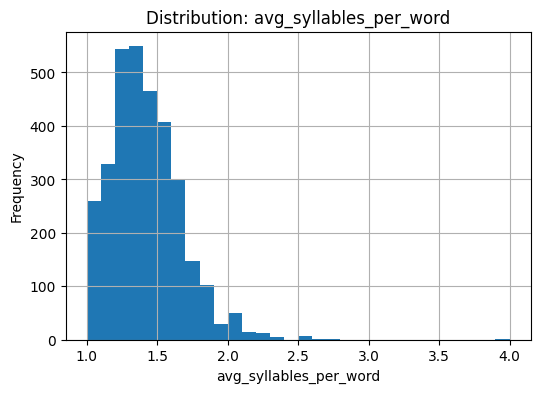

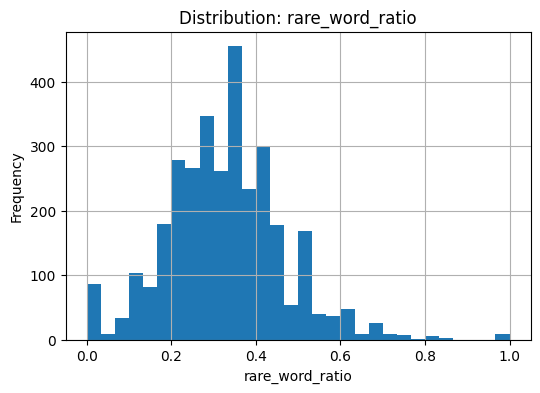

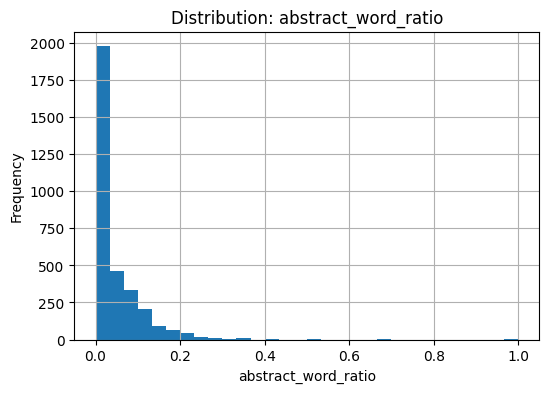

,feature,skewness,abs_skewness
0,word_count,12.010,12.010
3,abstract_word_ratio,3.903,3.903
1,avg_syllables_per_word,1.367,1.367
2,rare_word_ratio,0.465,0.465


,feature,skewness,abs_skewness,distribution_shape
0,word_count,12.010,12.010,strongly skewed
3,abstract_word_ratio,3.903,3.903,strongly skewed
1,avg_syllables_per_word,1.367,1.367,strongly skewed
2,rare_word_ratio,0.465,0.465,approximately symmetric


Suggested transformation checks:

- word_count: consider log transform or winsorization
- abstract_word_ratio: consider log transform or winsorization
- avg_syllables_per_word: consider log transform or winsorization
- rare_word_ratio: no transformation likely needed


In [8]:
candidate_features = [
    "word_count",
    "avg_syllables_per_word",
    "rare_word_ratio",
    "abstract_word_ratio"
]

# Visualize feature distributions

for feature in candidate_features:

    plt.figure(figsize=(6, 4))

    analysis_df[feature].hist(
        bins=30
    )

    plt.title(f"Distribution: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

# Compute skewness statistics

distribution_summary = []

for feature in candidate_features:

    skewness = analysis_df[feature].skew()

    distribution_summary.append({
        "feature": feature,
        "skewness": round(skewness, 3),
        "abs_skewness": round(abs(skewness), 3)
    })

distribution_df = pd.DataFrame(distribution_summary)

distribution_df = distribution_df.sort_values(
    "abs_skewness",
    ascending=False
)

display(distribution_df)

# Interpret skewness

def interpret_skewness(abs_skewness):

    if abs_skewness < 0.5:
        return "approximately symmetric"

    elif abs_skewness < 1:
        return "moderately skewed"

    else:
        return "strongly skewed"


distribution_df["distribution_shape"] = (
    distribution_df["abs_skewness"]
    .apply(interpret_skewness)
)

display(distribution_df)

# Optional transformation suggestions

print("Suggested transformation checks:\n")

for _, row in distribution_df.iterrows():

    feature = row["feature"]
    skewness = row["abs_skewness"]

    if skewness >= 1:

        print(f"- {feature}: consider log transform or winsorization")

    else:

        print(f"- {feature}: no transformation likely needed")

### 5.5 Transforming Select Features

We apply transformations so that:

 1. Extremely skewed features are compressed
 2. Features become more comparable
 3. No single feature dominates the composite score

Final transformed features will all be scaled to 0–1.

The following transformations will take place:

*   Word count: Remove extreme outliers then log transform
*   Abstract word ratio: Winsorization
*   Average syllables per word: Log transform
*   Rare word ratio: None






In [10]:
#### 5.5 Transform Selected Features

# Helper function for min-max scaling

def min_max_scale(series):

    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series([0] * len(series), index=series.index)

    return (series - min_val) / (max_val - min_val)

# 1. removing outliers and log transform of word count

analysis_df = analysis_df[analysis_df["word_count"]<=100]
analysis_df["word_count_transformed"] = np.log1p(
    analysis_df["word_count"]
)

analysis_df["word_count_scaled"] = min_max_scale(
    analysis_df["word_count_transformed"]
)

# 2. winsorization of abstract word ratio

analysis_df["abstract_word_ratio_winsorized"] = analysis_df["abstract_word_ratio"].clip(
    lower=analysis_df["abstract_word_ratio"].quantile(0.01),
    upper=analysis_df["abstract_word_ratio"].quantile(0.99)
)


# 3. log transform of average syllables per word

analysis_df["avg_syllables_per_word_transformed"] = np.log1p(
    analysis_df["avg_syllables_per_word"]
)

analysis_df["avg_syllables_scaled"] = min_max_scale(
    analysis_df["avg_syllables_per_word_transformed"]
)

# 4. no transformation of rare word ratio

analysis_df["rare_word_ratio_scaled"] = min_max_scale(
    analysis_df["rare_word_ratio"]
)

# inspecting transformed features

transformed_feature_columns = [
    "word_count_scaled",
    "abstract_word_ratio_winsorized",
    "avg_syllables_scaled",
    "rare_word_ratio_scaled"
]

analysis_df[transformed_feature_columns].describe()


,word_count_scaled,abstract_word_ratio_winsorized,avg_syllables_scaled,rare_word_ratio_scaled
count,3185.000000,3185.000000,3185.000000,3185.000000
mean,0.529320,0.037324,0.197679,0.323743
std,0.160601,0.056660,0.110922,0.139207
min,0.000000,0.000000,0.000000,0.000000
25%,0.412468,0.000000,0.122754,0.235294
50%,0.532921,0.000000,0.190282,0.320000
75%,0.636833,0.062500,0.267516,0.400000
max,1.000000,0.250000,1.000000,1.000000


## ~6. Creating Linguistic Elevation Score

We combine the four features into one score, assigining greater weight to the features with larger observed variance.

| Feature | Weight |
|---|---:|
| `word_count_score` | 0.30 |
| `avg_syllables_score` | 0.20 |
| `rare_word_ratio_score` | 0.30 |
| `abstract_word_ratio_score` | 0.20 |

In [11]:
WEIGHTS = {
    "word_count_scaled": 0.30,
    "avg_syllables_scaled": 0.20,
    "rare_word_ratio_scaled": 0.30,
    "abstract_word_ratio_winsorized": 0.20
}


# Compute composite linguistic elevation score

analysis_df["linguistic_elevation_score"] = (

    WEIGHTS["word_count_scaled"]
    * analysis_df["word_count_scaled"]

    +

    WEIGHTS["avg_syllables_scaled"]
    * analysis_df["avg_syllables_scaled"]

    +

    WEIGHTS["rare_word_ratio_scaled"]
    * analysis_df["rare_word_ratio_scaled"]

    +

    WEIGHTS["abstract_word_ratio_winsorized"]
    * analysis_df["abstract_word_ratio_winsorized"]

)

# Inspect score distribution

print(analysis_df["linguistic_elevation_score"].describe())

count    3185.000000
mean        0.302920
std         0.076003
min         0.000000
25%         0.257387
50%         0.309529
75%         0.356157
max         0.550000
Name: linguistic_elevation_score, dtype: float64


Observations:

Variance is limited in linguistic movement (mean=0.397, standard deviation=0.07), which suggests **MLK does not dramatically alternate between simple and  sophisticated language. Rather, he maintains a stable rhetorical baseline across much of his speech.**

Put differently, his linguistic dance is less of a sharp, dramatic tango and more of a steady, consistent waltz.

## ~7. Classifying Sentences as Elevation States

We now investigate: relative to MLK's own rhetorical baseline, when does the language become more grounded or more elevated?

We will classify each sentence using z-scores to calculate relative states:

| Score Range | State | Code |
|---|---|---|
| `z < -0.5` | Simple | `S` |
| `-0.5 <= z <= 0.5` | Medium | `M` |
| `z > 0.5` | Sophisticated | `H` |

Note we are not detecting universally sophisticated language. We are just tracking linguistic movement within MLK's baseline, recognizing the movement will consist of small steps rather than large and dramatic contrasts, given our previous findings.


In [12]:
# Calculating z-scores for linguistic elevation

analysis_df["elevation_zscore"] = (
    analysis_df["linguistic_elevation_score"]
    - analysis_df["linguistic_elevation_score"].mean()
) / analysis_df["linguistic_elevation_score"].std()


def classify_elevation(score):
    if score <= -0.5:
        return "Simple"
    elif score <= 0.5:
        return "Medium"
    else:
        return "Sophisticated"


def state_code(state):
    return {
        "Simple": "S",
        "Medium": "M",
        "Sophisticated": "H"
    }[state]


analysis_df["elevation_state"] = analysis_df["elevation_zscore"].apply(classify_elevation)
analysis_df["state_code"] = analysis_df["elevation_state"].apply(state_code)

analysis_df["elevation_state"].value_counts()


,count
elevation_state,
Medium,1249
Sophisticated,1053
Simple,883


## ~8. Validate the Scoring

We will now inspect our classifications to check whether they are meaningful.

In [13]:
def show_examples_by_state(state, n=10):
    examples = (
        analysis_df[analysis_df["elevation_state"] == state]
        .sort_values("linguistic_elevation_score", ascending=(state == "Simple"))
        .head(n)
    )
    return examples[["speech_id", "sentence_index", "linguistic_elevation_score", "sentence"]]


display(show_examples_by_state("Simple", n=10))
display(show_examples_by_state("Medium", n=10))
display(show_examples_by_state("Sophisticated", n=10))

,speech_id,sentence_index,linguistic_elevation_score,sentence
77,"#MLK _ But, If Not_sentences",77,0.000000,yes
632,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,264,0.000000,Yes.
630,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,262,0.000000,Yes.
3017,Martin Luther King's Sermon_ The Drum Major Instinct_sentences,171,0.000000,yeah
2995,Martin Luther King's Sermon_ The Drum Major Instinct_sentences,149,0.000000,right
1302,MLK_ Paul's Letter to American Christians_sentences,195,0.000000,yes
1307,MLK_ Paul's Letter to American Christians_sentences,200,0.000000,Yes
2662,"Martin Luther King Jr., _Why Jesus Called a Man a Fool_ August 27, 1967_sentences",16,0.031174,He died.
2982,Martin Luther King's Sermon_ The Drum Major Instinct_sentences,136,0.031174,so right
2154,"Martin Luther King Jr. 'Rediscovering Lost Values' February 28, 1954_sentences",215,0.053292,Fear not look.


,speech_id,sentence_index,linguistic_elevation_score,sentence
44,"#MLK _ But, If Not_sentences",44,0.340856,"They came to the point after saying, our God is able to deliver us from the burning fire, funnest."
152,"#MLK _ Nobel Peace Prize Lecture. Oslo, Norway. December 11, 1964._sentences",66,0.340836,"He has been caught up by the zeitgeist and with his black brothers of Africa and his brown and yellow brothers in Asia, South America and the Caribbean."
552,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,184,0.340825,"But the image of violence and militarism, unquote, we continue that will be no doubt in my mind, and in the mind of the world and we have no honorable intentions in the Vietnam."
805,I Have Been to the Mountaintop Full Speech_sentences,129,0.340731,But God has commanded us to be concerned about the slums down here and his children who can't eat three square meals a day.
916,I Have Been to the Mountaintop Full Speech_sentences,240,0.340721,"And that blade had gone through and the X-rays revealed that the tip of the blade was on the edge of my order, the main order."
667,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,299,0.340529,"Though we might prefer to wise, we must choose and choose a moment of history."
502,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,134,0.340335,How they judge us when our officials know that their membership is less than 25% Cummins and yet insist on giving them the blanket name.
3084,mlkyouthconference_sentences,59,0.340335,How can one avoid being depressed when he sees evidences with his own eyes of millions of people going to bed hungry at night?
1366,MLK_ The Other America_sentences,2,0.340333,"A few things that one could talk about before such a large, concerned and enlightened audience, there are so many problems facing our nation and our world that one could just t..."
1874,"Martin Luther King Jr. 'Love Your Enemies' November 17, 1957_sentences",275,0.340264,"One of the things that concerns me most is that in the list of the revolution of the world and the midst of the revolution of this nation, that we will discover the meaning of ..."


,speech_id,sentence_index,linguistic_elevation_score,sentence
1284,MLK_ Paul's Letter to American Christians_sentences,177,0.550000,America
1308,MLK_ Paul's Letter to American Christians_sentences,201,0.550000,America
176,"#MLK _ Nobel Peace Prize Lecture. Oslo, Norway. December 11, 1964._sentences",90,0.498314,"Until every mountain of pride and irrationality is made low by the leavening process of humility and compassion, until the rough places of injustice are transformed into a smal..."
1928,"Martin Luther King Jr. 'Love Your Enemies' November 17, 1957_sentences",329,0.495500,"It is an eternal reminder to a generation depending on nuclear and atomic energy, a generation depending on physical violence that love is the only creative, redemptive, transf..."
288,"#MLK _ Nobel Peace Prize Lecture. Oslo, Norway. December 11, 1964._sentences",202,0.492863,"On the contrary, the detonation of an atomic device by the first non-white non-western and so-called underdeveloped power, namely the Chinese People's Republic, opens new vista..."
601,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,233,0.490255,This way of settling differences is not just this business of burning human beings would lay on feeling our nation's homes with orphans and widows of injecting poisonous drugs ...
2239,"Martin Luther King Jr. - 'Give Us the Ballot' Speech - May 17, 1957_sentences",0,0.487280,"Mr. Chairman, distinguished platform associates, fellow Americans, three years ago, the Supreme Court of this nation rendered in simple, eloquent and unequivocal language, a de..."
163,"#MLK _ Nobel Peace Prize Lecture. Oslo, Norway. December 11, 1964._sentences",77,0.479035,"It came as a bright interlude in the long and sometimes turbulent struggle for civil rights, the beginning of a second emancipation proclamation, providing a comprehensive lega..."
3124,mlkyouthconference_sentences,99,0.477997,Now certainly many of the scholars and in academic circles we have found individuals working in these areas and they've made it clear that that is no evidence for this great an...
585,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,217,0.476442,"This need to maintain social stability for our investment, accounts for the counter-revolutionary action of American forces in Guatemala."


The classfications aren't perfect, but still may give meaningful signal.

## ~9. Create the Rhetorical Rhythm Timeline

Now we convert each speech into a sequence of states to illustrate MLK's "dance rhythm:"

```text
Ex: S S S M H H S M H S
```



In [14]:
rhythm_sequences = (
    analysis_df
    .sort_values(["speech_id", "sentence_index"])
    .groupby("speech_id")["state_code"]
    .apply(lambda codes: " ".join(codes))
    .reset_index(name="rhetorical_rhythm_sequence")
)

rhythm_sequences.head()


,speech_id,rhetorical_rhythm_sequence
0,"#MLK _ But, If Not_sentences",M M H M H H S H H H H M M H H H M H M H H M M H M M M H S M M S S M M S M H S M M M S S M S S M H H S H M H H S M H S M M M S M M H M H H S S H S H S M S H M H H M H S M
1,"#MLK _ Nobel Peace Prize Lecture. Oslo, Norway. December 11, 1964._sentences",H H H H S M H M M M H M M M M M H H H M H H H H H H H M M M H H M S H H H H H H M H H H M H M M H H H M M H M M S M M M M H H M H H M H H H H H H H H H H H M H H H H H S M H H ...
2,Beyond Vietnam-A Time to Break Silence 4-4-67_sentences,H M M H H M M H H S M M M S H S H H M H H S M M S H M M M H M S H H H H H M M M H M H M H H H H H M H M H S H H H S H H M H H H S H H M M H H M M M S M S M H S H M H H M M H H ...
3,I Have Been to the Mountaintop Full Speech_sentences,H M S M M S H S H S S H M S M S M S M S H M H M M H M M S H S H S M M S M H S H S M M M S S M M S S S S S S M H H S M H M S M H M M S H S M M H M M S H S M S M M M M M M S S M ...
4,MLKDream_64kb_sentences,H H H H M M H H H H H S M H H M M H M M M H H S M H S H H H M M H H M M S S S S S S M M S M H H S S H M M H S S S S S M M M S M H M M H H M S H M S M H S S M H H S M H M S H H ...


### 9.1 Visual Timeline for One Speech

This strip plot shows the sequence of Simple, Medium, and Sophisticated sentences across one speech.


/tmp/ipykernel_6733/2148116092.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  speech_df["state_number"] = speech_df["state_code"].map(state_to_number)


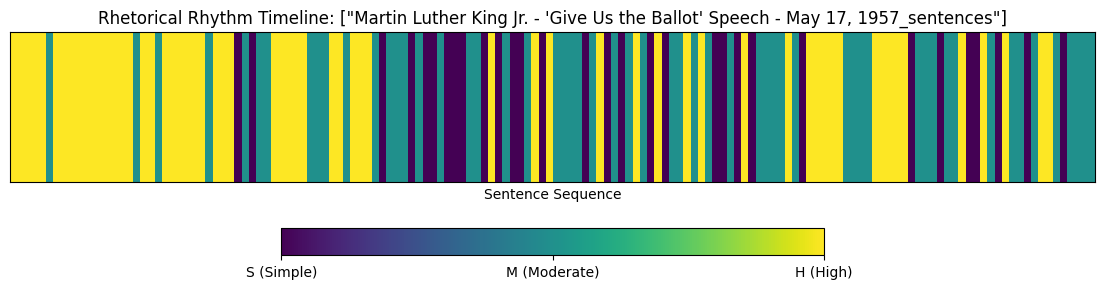

Saved timeline to: /content/drive/MyDrive/mlk_rhetoric_analysis/visuals/rhetorical_rhythm_timeline_["Martin Luther King Jr. - 'Give Us the Ballot' Speech - May 17, 1957_sentences"].png


In [19]:
import matplotlib.patches as mpatches

speech_df = analysis_df[analysis_df['speech_id']=="Martin Luther King Jr. - 'Give Us the Ballot' Speech - May 17, 1957_sentences"]
selected_speech = speech_df['speech_id'].unique()

state_to_number = {"S": 0, "M": 1, "H": 2}
speech_df["state_number"] = speech_df["state_code"].map(state_to_number)

plt.figure(figsize=(14, 3)) # Slightly taller to accommodate the colorbar
im = plt.imshow([speech_df["state_number"].values], aspect="auto", cmap="viridis")

# Add color legend
cbar = plt.colorbar(im, orientation='horizontal', pad=0.2, shrink=0.5)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(["S (Simple)", "M (Moderate)", "H (High)"])

plt.yticks([])
plt.xticks([])
plt.title(f"Rhetorical Rhythm Timeline: {selected_speech}")
plt.xlabel("Sentence Sequence")

timeline_path = visuals_dir / f"rhetorical_rhythm_timeline_{selected_speech}.png"
plt.savefig(timeline_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved timeline to: {timeline_path}")


## ~10. Motif Analysis

A motif is a recurring short sequence of rhetorical states.

Examples:

```text
S-S-H
S-M-H
H-H-S
S-H-S
```

These motifs can be interpreted as rhetorical dance steps.


In [23]:
def extract_motifs(codes, motif_length=3):
    return ["-".join(codes[i:i + motif_length]) for i in range(len(codes) - motif_length + 1)]


motif_records = []

for speech_id, group in analysis_df.sort_values(["speech_id", "sentence_index"]).groupby("speech_id"):
    codes = group["state_code"].tolist()
    for motif_length in [3, 4, 5]:
        motifs = extract_motifs(codes, motif_length=motif_length)
        for motif in motifs:
            motif_records.append({
                "speech_id": speech_id,
                "motif_length": motif_length,
                "motif": motif
            })

motifs_df = pd.DataFrame(motif_records)

motif_summary = (
    motifs_df
    .groupby(["motif_length", "motif"])
    .size()
    .reset_index(name="count")
    .sort_values(["motif_length", "count"], ascending=[True, False])
)

motif_summary.head(20)


,motif_length,motif,count
0,3,H-H-H,284
13,3,M-M-M,215
26,3,S-S-S,167
14,3,M-M-S,162
1,3,H-H-M,159
9,3,M-H-H,158
22,3,S-M-M,157
4,3,H-M-M,152
12,3,M-M-H,145
25,3,S-S-M,141


## ~11. Exporting Results

In [22]:
sentence_level_path = output_dir / "sentence_level_linguistic_elevation.csv"
rhythm_sequences_path = output_dir / "rhetorical_rhythm_sequences.csv"
motif_summary_path = output_dir / "linguistic_elevation_motif_summary.csv"

analysis_df.to_csv(sentence_level_path, index=False)
rhythm_sequences.to_csv(rhythm_sequences_path, index=False)
motif_summary.to_csv(motif_summary_path, index=False)

print("Saved files:")
print(sentence_level_path)
print(rhythm_sequences_path)
print(motif_summary_path)


Saved files:
/content/drive/MyDrive/mlk_rhetoric_analysis/data/linguistic_elevation/sentence_level_linguistic_elevation.csv
/content/drive/MyDrive/mlk_rhetoric_analysis/data/linguistic_elevation/rhetorical_rhythm_sequences.csv
/content/drive/MyDrive/mlk_rhetoric_analysis/data/linguistic_elevation/linguistic_elevation_transitions.csv
/content/drive/MyDrive/mlk_rhetoric_analysis/data/linguistic_elevation/linguistic_elevation_motif_summary.csv
